# Validate the energy-loss-corrected Parquet file

Independent consumer-side check using only the delivered corrected Parquet file. The notebook verifies the file metadata and plots the Forward Detector momentum residual for all four generated particle species.

In [1]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.dataset as ds
import pyarrow.parquet as pq


In [2]:
# Open and inspect only the delivered corrected Parquet file.
CORRECTED_PARQUET_PATH = Path(
    "parquet/"
    "el_pip_pim_proton_phasepspace_allgen_20M_"
    "energy_loss_corrected.parquet"
).resolve()

if not CORRECTED_PARQUET_PATH.is_file():
    raise FileNotFoundError(
        f"Corrected Parquet file not found: {CORRECTED_PARQUET_PATH}"
    )

corrected_dataset = ds.dataset(
    CORRECTED_PARQUET_PATH,
    format="parquet",
)
corrected_parquet_file = pq.ParquetFile(
    CORRECTED_PARQUET_PATH
)
corrected_schema = corrected_dataset.schema
corrected_rows = corrected_dataset.count_rows()

REQUIRED_COLUMNS = {
    "pid_gen",
    "reconstructed",
    "detector",
    "p_gen",
    "p_rec",
    "delta_p",
}
missing_columns = sorted(
    REQUIRED_COLUMNS - set(corrected_schema.names)
)
assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)
assert corrected_rows == corrected_parquet_file.metadata.num_rows

preview = corrected_dataset.scanner(
    columns=[
        "file_id",
        "event",
        "pid_gen",
        "reconstructed",
        "detector",
        "p_gen",
        "p_rec",
        "delta_p",
    ]
).head(10).to_pandas()

print(f"Corrected Parquet file: {CORRECTED_PARQUET_PATH}")
print(
    f"File size: "
    f"{CORRECTED_PARQUET_PATH.stat().st_size / 1024**3:.3f} GiB"
)
print(f"Rows: {corrected_rows:,}")
print(f"Columns: {len(corrected_schema.names)}")
print(
    f"Parquet row groups: "
    f"{corrected_parquet_file.metadata.num_row_groups:,}"
)
display(preview)


Corrected Parquet file: /Users/aleksandr.bulgakov/Desktop/work/BNL_ELoss_regression/parquet/el_pip_pim_proton_phasepspace_allgen_20M_energy_loss_corrected.parquet
File size: 7.587 GiB
Rows: 79,280,000
Columns: 40
Parquet row groups: 406


,file_id,event,pid_gen,reconstructed,detector,p_gen,p_rec,delta_p
0,0,0,11,1,1,5.704890,5.707592,-0.002703
1,0,0,211,1,1,5.971926,5.932404,0.039523
2,0,0,-211,1,1,6.514022,6.580482,-0.066460
3,0,0,2212,1,1,3.432360,3.421755,0.010605
4,0,1,11,0,0,5.003859,NaN,NaN
5,0,1,211,1,1,4.386706,4.380074,0.006632
6,0,1,-211,1,1,1.870302,0.938718,0.931583
7,0,1,2212,1,2,1.546968,1.569419,-0.022451
8,0,2,11,1,1,5.574865,5.585637,-0.010772
9,0,2,211,0,0,5.384797,NaN,NaN


Maximum |delta_p - (p_gen - p_rec)|: 0.000e+00 GeV


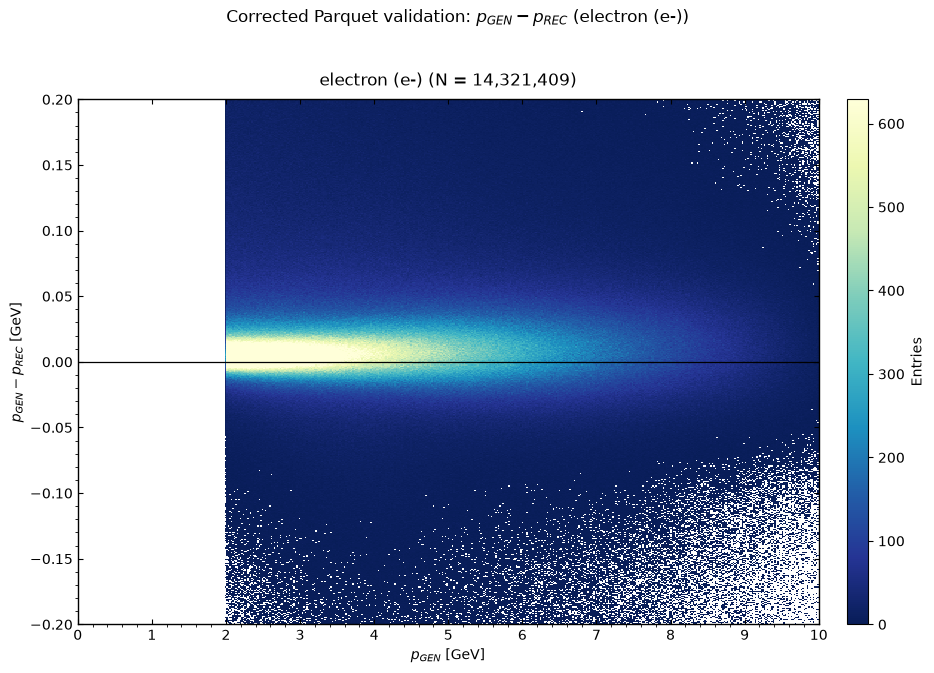

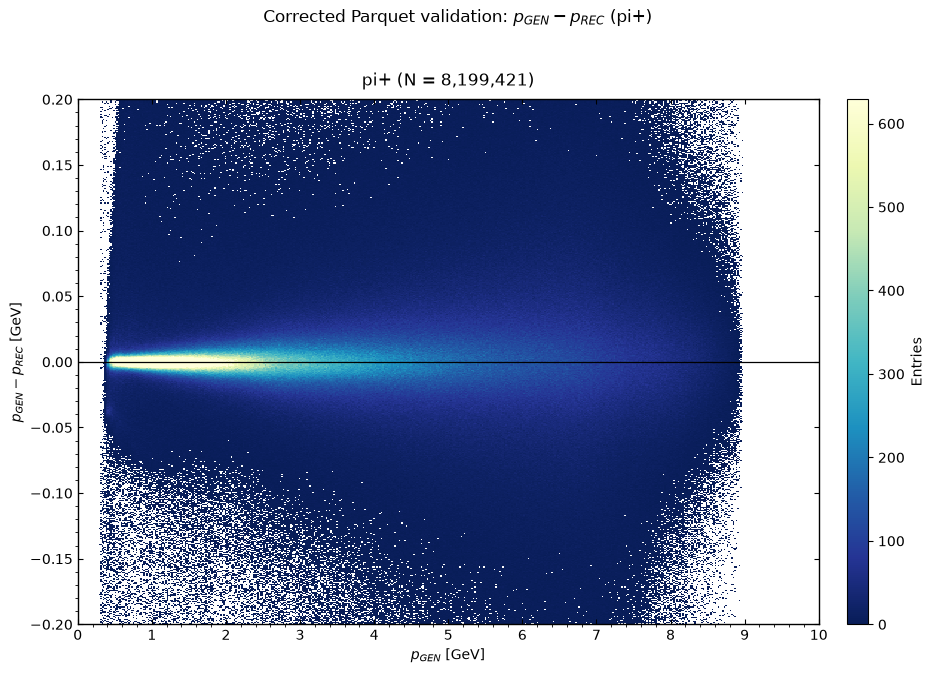

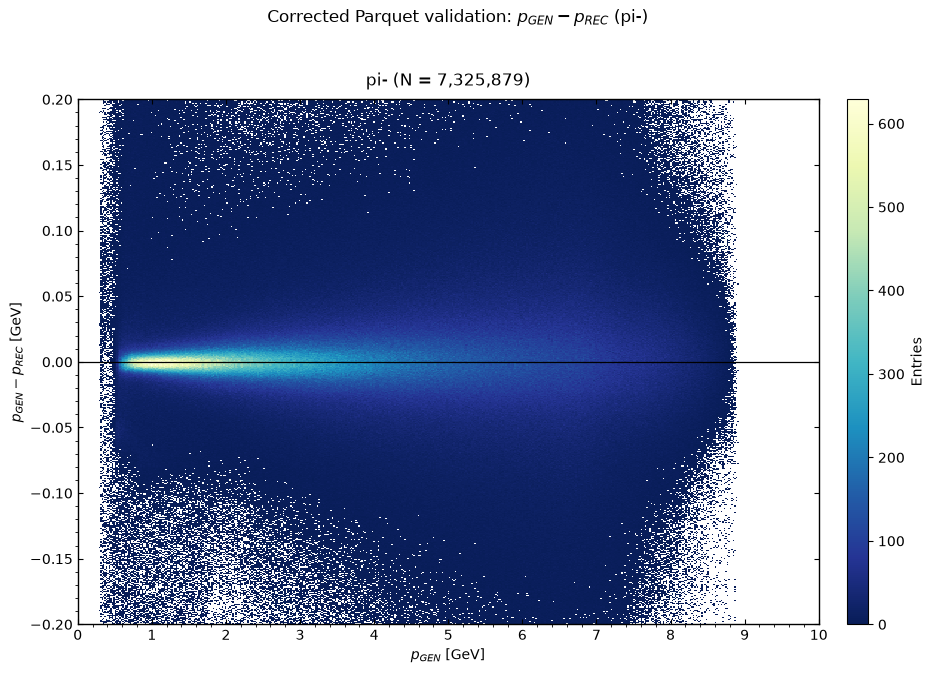

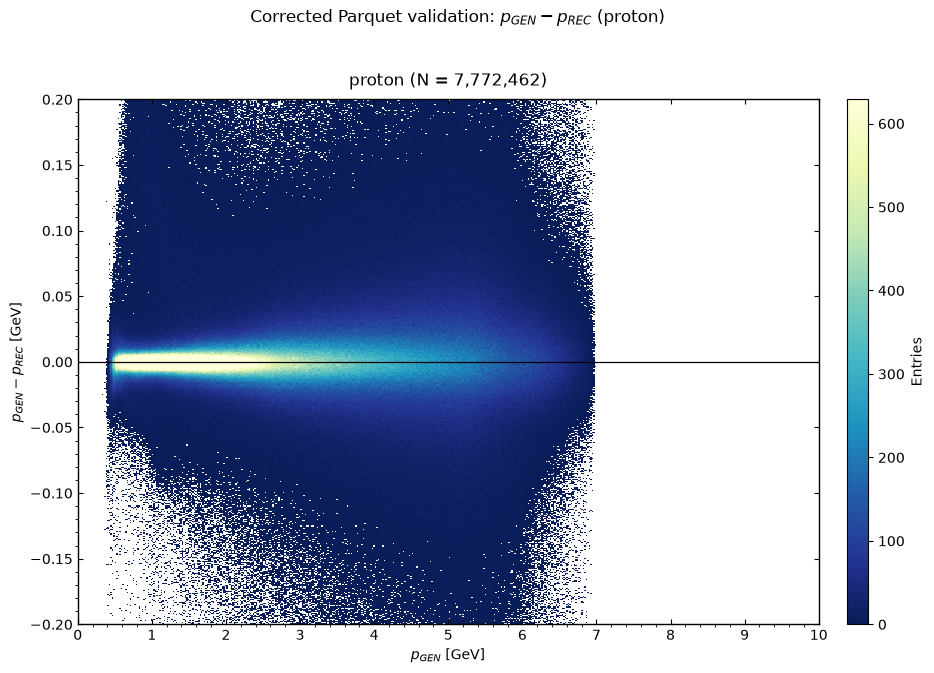

In [3]:
# Plot corrected delta_p versus p_gen for reconstructed FD rows.
PARTICLE_NAMES_BY_PID = {
    11: "electron (e-)",
    211: "pi+",
    -211: "pi-",
    2212: "proton",
}
PARTICLE_PIDS = list(PARTICLE_NAMES_BY_PID)
PLOT_COLUMNS = ["pid_gen", "p_gen", "p_rec", "delta_p"]
P_GEN_BINS = np.linspace(0.0, 10.0, 500)
DELTA_P_LIMITS = (-0.2, 0.2)
DELTA_P_BINS = np.linspace(*DELTA_P_LIMITS, 500)
DELTA_P_TICKS = np.arange(-0.2, 0.201, 0.05)

histogram_counts = {
    pid: np.zeros(
        (
            len(DELTA_P_BINS) - 1,
            len(P_GEN_BINS) - 1,
        ),
        dtype=np.int64,
    )
    for pid in PARTICLE_PIDS
}
selected_row_counts = {pid: 0 for pid in PARTICLE_PIDS}
maximum_delta_p_consistency_error = 0.0

FD_RECONSTRUCTED_CUT = (
    (ds.field("reconstructed") == 1)
    & (ds.field("detector") == 1)
    & ds.field("pid_gen").isin(PARTICLE_PIDS)
)

for record_batch in corrected_dataset.scanner(
    columns=PLOT_COLUMNS,
    filter=FD_RECONSTRUCTED_CUT,
    batch_size=250_000,
    use_threads=True,
    batch_readahead=2,
    fragment_readahead=1,
).to_batches():
    batch_df = record_batch.to_pandas()
    valid = (
        batch_df["pid_gen"].isin(PARTICLE_PIDS)
        & np.isfinite(batch_df["p_gen"])
        & np.isfinite(batch_df["p_rec"])
        & np.isfinite(batch_df["delta_p"])
    )
    batch_df = batch_df.loc[valid]
    if batch_df.empty:
        continue

    consistency_error = np.abs(
        batch_df["delta_p"].to_numpy()
        - (
            batch_df["p_gen"].to_numpy()
            - batch_df["p_rec"].to_numpy()
        )
    )
    maximum_delta_p_consistency_error = max(
        maximum_delta_p_consistency_error,
        float(consistency_error.max()),
    )

    for pid in PARTICLE_PIDS:
        species_df = batch_df[batch_df["pid_gen"] == pid]
        selected_row_counts[pid] += len(species_df)
        histogram, _, _ = np.histogram2d(
            species_df["delta_p"],
            species_df["p_gen"],
            bins=[DELTA_P_BINS, P_GEN_BINS],
        )
        histogram_counts[pid] += histogram.astype(np.int64)

assert maximum_delta_p_consistency_error < 1e-4, (
    "delta_p is inconsistent with p_gen - p_rec: "
    f"maximum difference = {maximum_delta_p_consistency_error}"
)
print(
    "Maximum |delta_p - (p_gen - p_rec)|: "
    f"{maximum_delta_p_consistency_error:.3e} GeV"
)

positive_counts = np.concatenate(
    [
        counts[counts > 0]
        for counts in histogram_counts.values()
    ]
)
colorbar_max = max(
    1,
    np.percentile(positive_counts, 99.5),
)
plot_cmap = (
    plt.colormaps["YlGnBu_r"].with_extremes(bad="white")
)

# Linear color scale only, matching the original diagnostic plots.
for pid, particle_name in PARTICLE_NAMES_BY_PID.items():
    figure, axis = plt.subplots(
        1,
        1,
        figsize=(9.5, 7.5),
        facecolor="white",
    )
    image = axis.pcolormesh(
        P_GEN_BINS,
        DELTA_P_BINS,
        np.ma.masked_less(histogram_counts[pid], 1),
        shading="auto",
        cmap=plot_cmap,
        vmin=0,
        vmax=colorbar_max,
    )
    axis.axhline(0.0, color="black", linewidth=0.9)
    axis.set_title(
        f"{particle_name} "
        f"(N = {selected_row_counts[pid]:,})",
        pad=10,
    )
    axis.set_xlabel(r"$p_{GEN}$ [GeV]")
    axis.set_ylabel(r"$p_{GEN} - p_{REC}$ [GeV]")
    axis.set_xlim(0.0, 10.0)
    axis.set_ylim(*DELTA_P_LIMITS)
    axis.set_xticks(np.arange(0.0, 10.1, 1.0))
    axis.set_yticks(DELTA_P_TICKS)
    axis.tick_params(
        axis="both",
        direction="in",
        top=True,
        right=True,
        labelleft=True,
    )
    axis.minorticks_on()
    axis.grid(False)

    for spine in axis.spines.values():
        spine.set_linewidth(1.0)

    figure.subplots_adjust(
        left=0.10,
        right=0.88,
        bottom=0.14,
        top=0.84,
    )
    colorbar_axis = figure.add_axes(
        [0.91, 0.14, 0.022, 0.70]
    )
    figure.colorbar(
        image,
        cax=colorbar_axis,
        label="Entries",
    )
    figure.suptitle(
        "Corrected Parquet validation: "
        rf"$p_{{GEN}} - p_{{REC}}$ ({particle_name})",
        y=0.96,
    )
    figure.patch.set_facecolor("white")
    plt.show()
